<center>
<img src="https://drive.google.com/uc?id=1f1gGVI-rxcHjA90WEGNvvtSXF1pAxQwg" alt="Fasilkom UI" width="300"/>

CSCE604037 • Penambangan Data

Semester Genap 2024/2025

Fakultas Ilmu Komputer, Universitas Indonesia

## **Lab 8: *Graph Mining***

### **Tenggat Waktu: 28 Maret 2025, 23.59 WIB**
</center>

### **Ketentuan:**

1. Dokumen *template* lab dengan format .ipynb dan dataset (jika dibutuhkan) telah disediakan di SCeLE
2. Jalankan kode pada dokumen .ipynb dan perhatikan dengan saksama apa yang potongan kode tersebut lakukan beserta dengan keluarannya. Jawablah pertanyaan yang disisipkan pada potongan program yang diberikan.
3. Dokumen Jupyter Notebook yang telah dilengkapi dengan jawaban dikumpulkan dengan format penamaan **Kelas_LabX_NPM_Nama.ipynb**. Contoh: A_Lab8_2106705026_KevinAlexander.ipynb
4. Kumpulkan dokumen tersebut pada submisi yang telah disediakan di SCeLE sebelum tenggat waktu yang ditentukan. Keterlambatan pengumpulan akan dikenakan penalti sebanyak **satu poin per menit**.
5. Lab ini dirancang sebagai **tugas mandiri**. Plagiarisme tidak diperkenankan dalam bentuk apapun. Adapun kolaborasi berupa diskusi (tanpa menyalin maupun mengambil jawaban orang lain) dan literasi masih diperbolehkan dengan mencantumkan kolaborator dan sumber.

**Nama**: Mohamad Arvin Fadriansyah

**Kelas**: A

**NPM**: 2006596996

**Kolaborator** (jika ada):
- Nama - NPM

**Referensi** (jika ada):
- [Referensi](https://example.com)

## Import Library

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

## Deskripsi Tugas: Graph Mining untuk Jaringan Jalan

Penambangan data dalam bentuk graf memiliki beberapa keuntungan dibandingkan bentuk tabular, terutama jika permasalahan yang ingin diselesaikan berfokus pada hubungan antar data. Salah satu permasalahan umum yang dapat diselesaikan melalui teori graf adalah perencanaan tata kelola suatu kota, contohnya adalah pembangunan gedung pemadam kebakaran. Pembangunan gedung tersebut harus berlokasi di daerah dengan aksesbilitas yang tinggi sehingga dapat pergi ke seluruh lokasi pada satuan wilayahnya dengan mudah dan cepat. Nilai aksesbilitas ini dapat dihitung menggunakan nilai *centrality*, yaitu *closeness centrality*.

Dalam tugas ini, disediakan *dataset* berupa jaringan jalan pada Kota Chesapeake. Anda diminta untuk menganalisis keterhubungan dalam kota tersebut dengan melakukan penambangan data graf. Harapannya, Anda dapat melakukan pengelolaan wilayah dengan lebih baik, misalnya dengan melihat keterhubungan suatu daerah atau pencarian lokasi dengan kepadatan jalan tertinggi.

## Tugas Anda

Anda diminta untuk melakukan pencarian terhadap beberapa permasalahan pengelolaan wilayah berikut:
- Menentukan lokasi kepadatan jalan suatu wilayah melalui nilai *centrality*,
- Memetakan wilayah untuk mengetahui karakteristik suatu daerah menggunakan *community detection*, dan
- Mencari pola lintasan jalan yang mirip menggunakan *frequent pattern mining*.

Sebagai tambahan materi, Anda juga akan menggunakan *dataset* lain, yaitu *cybersecurity education* untuk permasalahan berikut:
- Melakukan *graph embedding* pada *dataset cybersecurity education* untuk keperluan pembelajaran mesin, seperti klasifikasi jenis serangan.

## Informasi Mengenai *Dataset* Road Chesapeake

Informasi yang disimpan pada *dataset* Road Chesapeake merupakan kumpulan *node* dan *edge* dalam bentuk *weighted directed graph*. *Node* dapat dianalogikan sebagai suatu lokasi dan *edge* merupakan jalan yang dari lokasi pertama ke lokasi kedua dengan panjang tertentu. Graf ini telah disederhanakan dengan menghilangkan informasi koordinat lokasi, mengganti nama *node* dengan kode lokasi, serta menghilangkan *edge* yang duplikat (memiliki Road1 dan Road2 yang sama). Berikut adalah rincian informasi tersebut:
- **Road1**: Kode nama lokasi 1.
- **Road2**: Kode nama lokasi 2.
- **Length**: Panjang jalan dari lokasi 1 menuju lokasi 2.
---

## Load Dataset ke dalam Graph (NetworkX)

Untuk mempermudah pengerjaan, dataset akan di-load menggunakan library NetworkX. Jalankan cell di bawah untuk dapat melanjutkan ke tahap berikutnya.

In [2]:
# Load CSV
df = pd.read_csv("./road-network-chesapeake.csv")

In [5]:
# Load dataset
G = nx.DiGraph()

for ind in df.index:
  road1 = df['Road1'][ind]
  road2 = df['Road2'][ind]
  length = df['Length'][ind]

  G.add_edge(road1, road2, weight=length)

# Check added nodes and edges
list(G.edges)

[('G', 'A'),
 ('G', 'B'),
 ('G', 'C'),
 ('G', 'F'),
 ('A', 'A'),
 ('A', 'B'),
 ('A', 'E'),
 ('A', 'G'),
 ('A', 'H'),
 ('H', 'A'),
 ('H', 'B'),
 ('H', 'G'),
 ('K', 'A'),
 ('K', 'B'),
 ('K', 'G'),
 ('K', 'H'),
 ('B', 'A'),
 ('B', 'B'),
 ('B', 'E'),
 ('B', 'F'),
 ('B', 'G'),
 ('B', 'H'),
 ('B', 'I'),
 ('B', 'J'),
 ('D', 'A'),
 ('D', 'C'),
 ('D', 'D'),
 ('F', 'A'),
 ('F', 'B'),
 ('F', 'C'),
 ('F', 'D'),
 ('F', 'E'),
 ('F', 'F'),
 ('F', 'G'),
 ('F', 'H'),
 ('F', 'I'),
 ('F', 'J'),
 ('I', 'B'),
 ('I', 'G'),
 ('I', 'H'),
 ('C', 'B'),
 ('C', 'C'),
 ('C', 'D'),
 ('C', 'I'),
 ('C', 'J'),
 ('E', 'C'),
 ('E', 'H'),
 ('J', 'H'),
 ('J', 'I')]

## Node Centrality

Node centrality adalah ukuran yang digunakan untuk menentukan sejauh mana suatu node penting atau berpengaruh dalam suatu graf. Ada beberapa metrik node centrality yang umum digunakan:
- Degree centrality
- Closeness centrality
- Betweenness centrality

Sebagai contoh dalam graf jaringan jalan, degree centrality dapat digunakan untuk mengukur seberapa banyak suatu lokasi terhubung dengan jalan yang ada. Closeness centrality dapat digunakan untuk mengetahui aksesibilitas suatu lokasi. Sedangkan betweenness centrality dapat dianggap sebagai seberapa penting suatu lokasi dalam jaringan jalan tersebut. Tingkat kepentingan dari suatu lokasi dapat dilihat dari seberapa banyak akses antara dua lokasi lain yang dapat terhubung melalui lokasi tersebut.

### SOAL 1: Degree Centrality

Hitunglah in-degree dan out-degree dari masing-masing node, kemudian hitung total degree (in-degree + out-degree). Format luaran yang harus ditampilkan adalah nilai in-degree, nilai out-degree, total degree, dan hubungannya dengan node lain. Contoh luaran (**bukan jawaban sebenarnya**):

=======

Node A memiliki 5 in-degree, 6 out-degree, dan 11 total degree

in-degree = [B, C, D, E, F]

out-degree = [D, E, F, G, H, I]

=======

Node B memiliki 2 in-degree, 1 out-degree, dan 3 total degree

in-degree = [D, E, F]

out-degree = [A, C, D]

=======

In [6]:
print("=== Soal 1: Degree Centrality ===\n")
for node in G.nodes():
    in_deg = G.in_degree(node)
    out_deg = G.out_degree(node)
    total_deg = in_deg + out_deg
    in_neighbors = list(G.predecessors(node))
    out_neighbors = list(G.successors(node))
    print("=======")
    print(f"Node {node} memiliki {in_deg} in-degree, {out_deg} out-degree, dan {total_deg} total degree")
    print(f"in-degree = {in_neighbors}")
    print(f"out-degree = {out_neighbors}")
print("=======")


=== Soal 1: Degree Centrality ===

Node G memiliki 6 in-degree, 4 out-degree, dan 10 total degree
in-degree = ['H', 'I', 'K', 'A', 'B', 'F']
out-degree = ['A', 'B', 'C', 'F']
Node A memiliki 7 in-degree, 5 out-degree, dan 12 total degree
in-degree = ['G', 'H', 'K', 'A', 'B', 'D', 'F']
out-degree = ['A', 'B', 'E', 'G', 'H']
Node H memiliki 7 in-degree, 3 out-degree, dan 10 total degree
in-degree = ['I', 'J', 'K', 'A', 'B', 'E', 'F']
out-degree = ['A', 'B', 'G']
Node K memiliki 0 in-degree, 4 out-degree, dan 4 total degree
in-degree = []
out-degree = ['A', 'B', 'G', 'H']
Node B memiliki 8 in-degree, 8 out-degree, dan 16 total degree
in-degree = ['G', 'H', 'I', 'K', 'A', 'B', 'C', 'F']
out-degree = ['A', 'B', 'E', 'F', 'G', 'H', 'I', 'J']
Node D memiliki 3 in-degree, 3 out-degree, dan 6 total degree
in-degree = ['F', 'C', 'D']
out-degree = ['A', 'C', 'D']
Node F memiliki 3 in-degree, 10 out-degree, dan 13 total degree
in-degree = ['G', 'B', 'F']
out-degree = ['A', 'B', 'C', 'D', 'E', 'F',

### SOAL 2a: Closeness Centrality

Hitunglah closeness centrality dari *node* B dengan mempertimbangkan weight (length) pada setiap *edge*. Format luaran yang diharapakan untuk setiap node lain dituliskan juga alur *node* yang dilewati. Contoh luaran (**bukan jawaban sebenarnya**):

=======

Asumsikan bahwa contoh luaran ini hanya terdiri dari node A, B, C, dan D saja.

- B ke A = A(1) = 1
- B ke C = A(1) + C(2) = 3
- B ke D = A(1) + D(3) = 4

Total Shortest Path untuk node B = 1 + 3 + 4 = 8

Closeness Centrality untuk node B = 1 / (Total Shortest Path) = 1 / 8 = 0.125

=======

**Jangan lupa bahwa ini adalah directed graph sehingga perlu memperhatikan arahnya juga. Harap diingat juga bahwa closeness yang dihitung hanyalah shortest path dari B ke *node* lain (*out-degree*)**

In [8]:
print("\nCloseness Centrality (weighted) untuk node B ===\n")
try:
    # Hitung jarak dan path terpendek dari node 'B' dengan mempertimbangkan weight
    weighted_distances = nx.single_source_dijkstra_path_length(G, source='B', weight='weight')
    weighted_paths = nx.single_source_dijkstra_path(G, source='B', weight='weight')
    
    total_distance = 0
    for target, distance in weighted_distances.items():
        if target == 'B':
            continue
        path = weighted_paths[target]
        # Buat output dengan rincian tiap edge
        edge_details = []
        cumulative = 0
        for i in range(len(path)-1):
            w = G[path[i]][path[i+1]]['weight']
            cumulative += w
            edge_details.append(f"{path[i+1]}({w})")
        print(f"B ke {target} = {' + '.join(edge_details)} = {cumulative}")
        total_distance += cumulative
        
    print(f"\nTotal Shortest Path untuk node B = {total_distance}")
    closeness_weighted = 1 / total_distance if total_distance != 0 else 0
    print(f"Closeness Centrality untuk node B = {closeness_weighted:.4f}")
except Exception as e:
    print("Error computing weighted closeness centrality:", e)



Closeness Centrality (weighted) untuk node B ===

B ke F = F(1) = 1
B ke G = G(1) = 1
B ke H = H(2) = 2
B ke J = J(2) = 2
B ke A = F(1) + A(1) = 2
B ke E = F(1) + E(1) = 2
B ke I = I(3) = 3
B ke D = F(1) + D(3) = 4
B ke C = F(1) + C(4) = 5

Total Shortest Path untuk node B = 22
Closeness Centrality untuk node B = 0.0455


### SOAL 2b: Closeness Centrality

Hitunglah closeness centrality dari node B tanpa mempertimbangkan weight/length (asumsikan seluruh edge weight-nya adalah 1). Format luaran yang diharapakan untuk setiap node lain dituliskan juga alur node yang dilewati. Contoh luaran (**bukan jawaban sebenarnya**):

=======

Asumsikan bahwa contoh luaran ini hanya terdiri dari node A, B, C, dan D saja.

- B ke A = A(1) = 1
- B ke C = A(1) + C(1) = 2
- B ke D = A(1) + D(1) = 2

Total Shortest Path node B = 1 + 2 + 2 = 5

Closeness Centrality node B = 1 / (Total Shortest Path) = 1 / 5 = 0.2

=======

**Jangan lupa bahwa ini adalah directed graph sehingga perlu memperhatikan arahnya juga. Harap diingat juga bahwa closeness yang dihitung hanyalah shortest path dari B ke *node* lain (*out-degree*)**

In [10]:
print("\n=== Closeness Centrality (unweighted) untuk node B ===\n")
unweighted_lengths = nx.single_source_shortest_path_length(G, source='B')
unweighted_paths = nx.single_source_shortest_path(G, source='B')

total_unweighted_distance = 0
for target, dist in unweighted_lengths.items():
    if target == 'B':
        continue
    path = unweighted_paths[target]
    # Karena setiap edge dianggap 1, tampilkan setiap langkah sebagai (1)
    edge_details = []
    for node in path[1:]:
         edge_details.append(f"{node}(1)")
    print(f"B ke {target} = {' + '.join(edge_details)} = {dist}")
    total_unweighted_distance += dist

print(f"\nTotal Shortest Path untuk node B = {total_unweighted_distance}")
closeness_unweighted = 1 / total_unweighted_distance if total_unweighted_distance != 0 else 0
print(f"Closeness Centrality untuk node B = {closeness_unweighted:.4f}")



=== Closeness Centrality (unweighted) untuk node B ===

B ke A = A(1) = 1
B ke E = E(1) = 1
B ke F = F(1) = 1
B ke G = G(1) = 1
B ke H = H(1) = 1
B ke I = I(1) = 1
B ke J = J(1) = 1
B ke C = E(1) + C(1) = 2
B ke D = F(1) + D(1) = 2

Total Shortest Path untuk node B = 11
Closeness Centrality untuk node B = 0.0909


### SOAL 3: Betweenness Centrality

Hitunglah betweeness centrality untuk seluruh node. Luaran yang dituliskan cukup nama node dengan nilai betweeneess. Contoh luaran (**bukan jawaban sebenarnya**):

=======

- B = 0.4
- C = 0.5

=======

In [12]:
print("\n=== Betweenness Centrality ===\n")
betweenness = nx.betweenness_centrality(G, normalized=True, weight='weight')
for node, bc in betweenness.items():
    print(f"{node} = {bc:.4f}")



=== Betweenness Centrality ===

G = 0.0833
A = 0.0444
H = 0.0185
K = 0.0000
B = 0.2907
D = 0.0278
F = 0.2093
I = 0.1083
C = 0.1611
E = 0.0315
J = 0.0000


## Frequent Pattern Mining

### SOAL 4: Visualisasikan Subgraf Berikut

In [13]:
# Jalankan kode berikut untuk mendapatkan subgraf untuk soal 5
subgraph = df.groupby(by="Road2").head(1).sort_values(by="Road2")


=== Visualisasi Subgraf ===



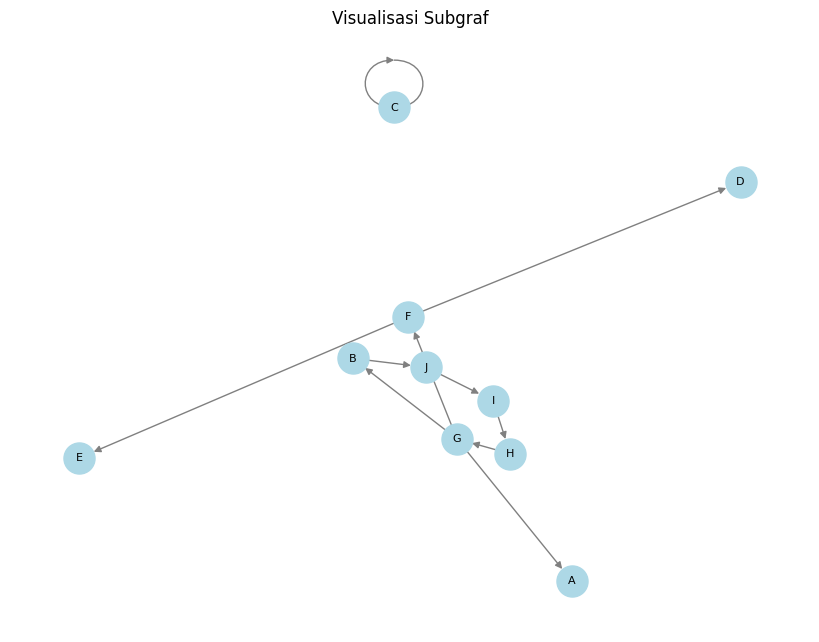

In [15]:
print("\n=== Visualisasi Subgraf ===\n")
# Membuat graf dari DataFrame subgraph (menggunakan kolom Road1, Road2, dan Length)
G_sub = nx.from_pandas_edgelist(subgraph, source='Road1', target='Road2', edge_attr='Length', create_using=nx.DiGraph())

plt.figure(figsize=(8,6))
nx.draw(G_sub, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500, font_size=8)
plt.title("Visualisasi Subgraf")
plt.show()


### SOAL 5: Frequent Pattern Mining

Ubah label *node* A - D menjadi label "Satu", label *node* E - G menjadi label "Dua", dan label *node* H - J menjadi label "Tiga". Tuliskan pola yang muncul lebih dari 1 kali pada subgraf di Soal 4 dengan jumlah maksimum *node* pada pola adalah 3. Contoh format luaran (**bukan jawaban sebenarnya**):

===

Asumsikan pola yang didapat dari subgraf pada Soal 4 adalah berikut:
- *A* -- 2 -- *B* diubah menjadi *Satu* -- 2 -- *Satu*
- *A* -- 4 -- *J* diubah menjadi *Satu* -- 4 -- *Tiga*
- *A* -- 2 -- *D* diubah menjadi *Satu* -- 2 -- *Satu*

Maka pola yang paling sering muncul adalah
- *Satu* -- 2 -- *Satu* sebanyak 2 kali
- *Satu* -- 4 -- *Tiga* sebanyak 1 kali

===

Perlu dicatat bahwa pola diatas hanyalah contoh, pencarian pola boleh menggunakan *node* lebih dari 2.

In [17]:
print("\n=== Frequent Pattern Mining ===\n")

# Fungsi untuk relabel node
def relabel_node(node):
    if node in ['A', 'B', 'C', 'D']:
        return "Satu"
    elif node in ['E', 'F', 'G']:
        return "Dua"
    elif node in ['H', 'I', 'J']:
        return "Tiga"
    else:
        return node

# Terapkan relabeling pada kolom Road1 dan Road2
subgraph['source_label'] = subgraph['Road1'].apply(relabel_node)
subgraph['target_label'] = subgraph['Road2'].apply(relabel_node)

# Buat kolom pattern dengan format "source_label -- Length -- target_label"
subgraph['pattern'] = subgraph['source_label'] + " -- " + subgraph['Length'].astype(str) + " -- " + subgraph['target_label']

# Hitung frekuensi pola
pattern_counts = subgraph['pattern'].value_counts()
print("Frekuensi semua pola:")
print(pattern_counts)

# Pilih pola yang muncul lebih dari 1 kali
frequent_patterns = pattern_counts[pattern_counts > 1]
print("\nPola yang sering muncul (lebih dari 1 kali):")
print(frequent_patterns)



=== Frequent Pattern Mining ===

Frekuensi semua pola:
pattern
Dua -- 4 -- Satu     2
Satu -- 4 -- Satu    1
Dua -- 3 -- Satu     1
Dua -- 1 -- Dua      1
Dua -- 4 -- Dua      1
Tiga -- 2 -- Dua     1
Tiga -- 1 -- Tiga    1
Tiga -- 2 -- Tiga    1
Satu -- 2 -- Tiga    1
Name: count, dtype: int64

Pola yang sering muncul (lebih dari 1 kali):
pattern
Dua -- 4 -- Satu    2
Name: count, dtype: int64


Maka pola yang paling sering muncul adalah
- *Dua* -- 4 -- *Satu* sebanyak 2 kali

## Community Detection

Community detection adalah salah satu task umum dalam menganalisis jaringan, seperti dalam struktur graf. Task ini berguna untuk mengidentifikasi suatu grup atau kelompok dalam jaringan yang kompleks. Dalam kasus jaringan jalan, task ini umumnya digunakan untuk menentukan karakteristik suatu daerah dalam pengembangan tata letak wilayah.

### SOAL 6: Algoritma Community Detection

Bagilah dataset menggunakan salah satu algoritma community detection lalu visualisasikan hasil pembagiannya. Jelaskan juga alasan pemilihan algoritma tersebut dan analisis hasil yang didapatkan.

In [20]:
print("\n=== Community Detection ===\n")
from networkx.algorithms import community

# Ubah graf directed menjadi undirected untuk deteksi komunitas
G_undirected = G.to_undirected()
communities = community.greedy_modularity_communities(G_undirected)
print("Komunitas yang terdeteksi:")
for i, comm in enumerate(communities):
    print(f"Community {i+1}: {list(comm)}")




=== Community Detection ===

Komunitas yang terdeteksi:
Community 1: ['G', 'A', 'K', 'H', 'B', 'E']
Community 2: ['I', 'J', 'C']
Community 3: ['F', 'D']


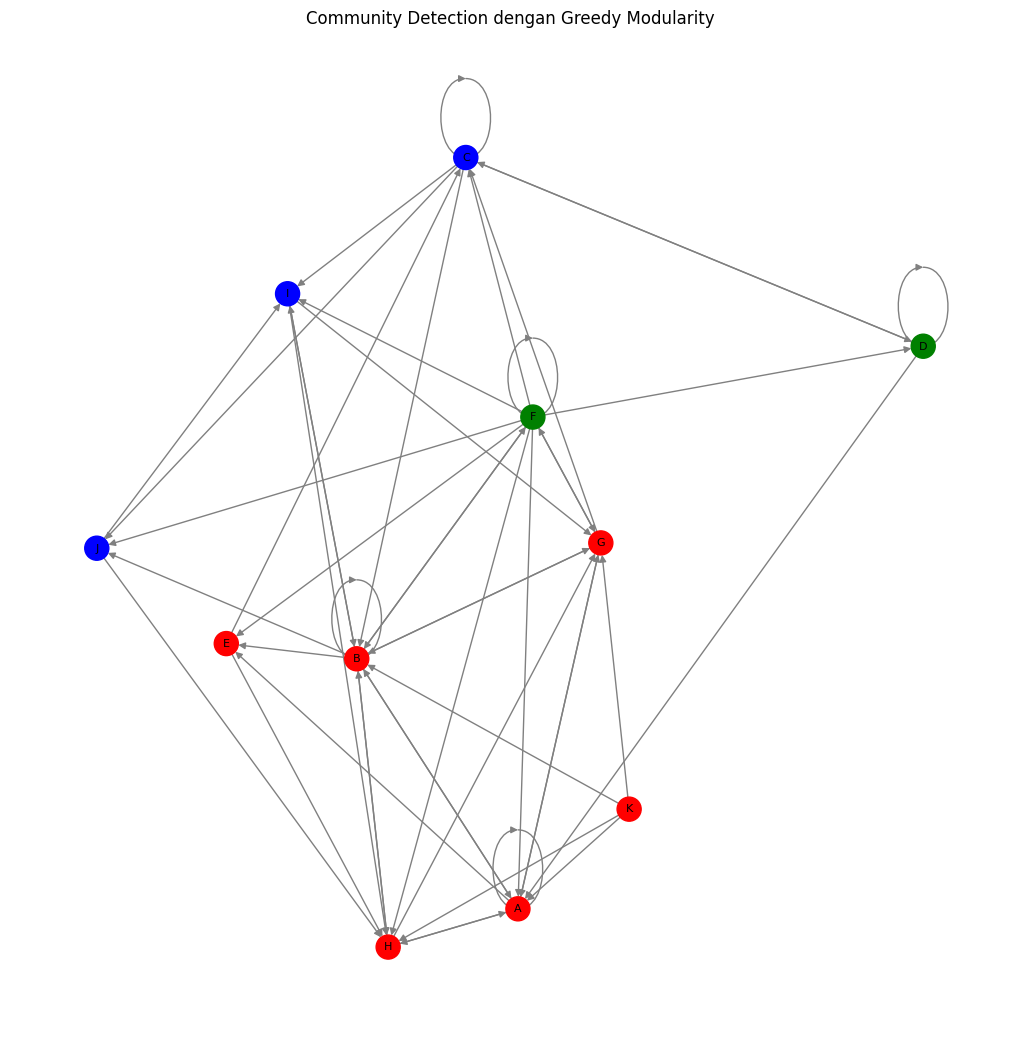

In [26]:
# Visualisasikan komunitas dengan pewarnaan berbeda
colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow']
color_map = {}
for i, comm in enumerate(communities):
    for node in comm:
        color_map[node] = colors[i % len(colors)]
node_colors = [color_map[node] for node in G.nodes()]

plt.figure(figsize=(10,10))
nx.draw(G, with_labels=True, node_color=node_colors, node_size=300, font_size=8, font_color='black', edge_color='gray')
plt.title("Community Detection dengan Greedy Modularity")
plt.show()



'''

Alsan pemilihan Algoritma greedy adalah modularity dipilih karena efisien untuk jaringan berukuran sedang dan mampu memaksimalkan modularitas, sehingga membantu mengidentifikasi kelompok komunitas yang saling terhubung dengan baik. Hasil visualisasi menunjukkan pembagian komunitas yang dapat membantu analisis karakteristik wilayah dalam jaringan jalan.

'''

## Graph Embedding

Berikut adalah visualisasi dari dataset yang digunakan.

- User View

<img src="https://user-images.githubusercontent.com/54346120/223224352-f4c5dfea-b843-4ecb-908b-62f1fd51faa5.png" alt="Fasilkom UI"/>

- Attacker View

<img src="https://user-images.githubusercontent.com/54346120/223224642-64b6c708-cbec-4711-a69f-3bfce73388d7.png" alt="Fasilkom UI"/>

- Security View

<img src="https://user-images.githubusercontent.com/54346120/223224862-d858feba-0947-4b99-97b9-6712751b2f34.png" alt="Fasilkom UI"/>

#### Instalasi dan Import PyKEEN

In [27]:
!pip install git+https://github.com/pykeen/pykeen.git

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
  Cloning https://github.com/pykeen/pykeen.git to c:\users\moham\appdata\local\temp\pip-req-build-f9iayac1
  Resolved https://github.com/pykeen/pykeen.git to commit 6e988d52672be3d5f3a03aa084fa4aaf5db74963
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.1 MB 1.1 MB/s eta 0:00:02
   -------------- ------------

  Running command git clone --filter=blob:none --quiet https://github.com/pykeen/pykeen.git 'C:\Users\moham\AppData\Local\Temp\pip-req-build-f9iayac1'

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
from pykeen.triples import TriplesFactory
from pykeen.pipeline import pipeline
from pykeen.evaluation import RankBasedEvaluator
from sklearn.model_selection import train_test_split

C:\Users\moham\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Creating Dataset for Embedding

In [29]:
df = pd.read_csv('embedding_triples.csv')
df = df.rename(columns={"e1": "subject", "r": "predicate", "e2": "object"})
df.head()

,subject,predicate,object
0,Attacks,can_harm,public domain
1,IDS,uses,Intrusion Detection
2,Snort,uses,Intrusion Detection
3,Snort,can_detect,network attacks
4,packet logger,is_part_of,Snort


In [30]:
train, test = train_test_split(df, test_size=0.2)

In [32]:
# Assuming your dataframe has columns 'subject', 'predicate', 'object'
training = TriplesFactory.from_labeled_triples(
    triples=train[['subject', 'predicate', 'object']].values,
)

testing = TriplesFactory.from_labeled_triples(
    triples=test[['subject', 'predicate', 'object']].values,
)

# Display the first few triples
training.triples

Reconstructing all label-based triples. This is expensive and rarely needed.


array([['/etc/rsyslogd/', 'can_analyze', 'folder'],
       ['/var/log', 'can_analyze', 'criticallog'],
       ['/var/log', 'can_analyze', 'files'],
       ...,
       ['zombie', 'has_a', 'IP ID'],
       ['zombie', 'has_a', 'port'],
       ['zombie host', 'has_a', 'port number']], dtype='<U39')

### SOAL 7: Graph Embedding Sederhana

Data graf dapat direpresentasikan menjadi data embedding yang digunakan oleh model pembelajaran mesin sebagai data input. Pada soal ini, mahasiswa diharapkan dapat memahami penggunaan graph embedding pada implementasi sederhana menggunakan PyKEEN. Silahkan mengubah atau menambahkan parameter pada kode pipeline di bawah (kecuali model, loss, training, testing, dan validation) untuk mendapatkan nilai Mean Reciprocal Rank tertinggi (mendekati 1). **Adanya perubahan pada parameter yang dilarang akan mengakibatkan pengurangan nilai**.

In [66]:
# result = pipeline(
#     model='TransE',
#     loss="softplus",
#     training=training,
#     testing=training,
#     validation=training,
#     model_kwargs=dict(embedding_dim=5),  # Increase the embedding dimension
#     optimizer_kwargs=dict(lr=0.2),  # Adjust the learning rate
#     training_kwargs=dict(num_epochs=100, use_tqdm_batch=False),  # Increase the number of epochs
# )
result = pipeline(
    model='TransE',
    loss="softplus",
    training=training,
    testing=training,
    validation=training,
    model_kwargs=dict(embedding_dim=50),         # Meningkatkan dimensi embedding
    optimizer_kwargs=dict(lr=0.0025),                # Menyesuaikan learning rate
    training_kwargs=dict(num_epochs=800, use_tqdm_batch=False),  # Meningkatkan jumlah epoch
)


INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
Training epochs on cpu: 100%|██████████| 800/800 [02:30<00:00,  5.33epoch/s, loss=0.469, prev_loss=0.465]
Evaluating on cpu:   0%|          | 0.00/583 [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 583/583 [00:00<00:00, 2.07ktriple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 0.30s seconds


In [67]:
# Create an evaluator
evaluator = RankBasedEvaluator()

# Evaluate the model
metrics = evaluator.evaluate(result.model, training.mapped_triples, additional_filter_triples=[testing.mapped_triples])

# Print the metrics
print(f"Hits@1: {metrics.get_metric('hits@1')}")
print(f"Hits@3: {metrics.get_metric('hits@3')}")
print(f"Hits@5: {metrics.get_metric('hits@5')}")
print(f"Hits@10: {metrics.get_metric('hits@10')}")
print(f"Mean Reciprocal Rank: {metrics.get_metric('mean_reciprocal_rank')}")

Evaluating on cpu:   0%|          | 0.00/583 [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 583/583 [00:00<00:00, 1.40ktriple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 0.43s seconds


Hits@1: 0.8036020583190394
Hits@3: 0.8970840480274442
Hits@5: 0.9279588336192109
Hits@10: 0.9605488850771869
Mean Reciprocal Rank: 0.8590567111968994
